In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("../data/retail_demand_dataset.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

Matplotlib is building the font cache; this may take a moment.


,date,store,store_type,product,price,competitor_price,promotion,discount_pct,sales,inventory,stockout,temperature,rainfall_mm,festival,day_of_week,is_weekend,supplier_lead_time
0,2022-01-01,Mumbai,supermarket,milk,46.25,45.87,0,0,88,121,0,31.541231,3.668696,0,5,1,3
1,2022-01-02,Mumbai,supermarket,milk,47.65,44.62,0,0,114,144,0,18.349936,19.398197,0,6,1,1
2,2022-01-03,Mumbai,supermarket,milk,46.74,44.80,0,0,87,111,0,23.172118,10.495129,0,0,0,2
3,2022-01-04,Mumbai,supermarket,milk,57.29,56.91,0,0,76,136,0,19.540309,12.367720,0,1,0,3
4,2022-01-05,Mumbai,supermarket,milk,46.22,47.92,1,18,87,156,0,20.898910,1.301032,0,2,0,3


Dataset Overview

In [2]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 109500 entries, 0 to 109499
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date                109500 non-null  datetime64[us]
 1   store               109500 non-null  str           
 2   store_type          109500 non-null  str           
 3   product             109500 non-null  str           
 4   price               109500 non-null  float64       
 5   competitor_price    109500 non-null  float64       
 6   promotion           109500 non-null  int64         
 7   discount_pct        109500 non-null  int64         
 8   sales               109500 non-null  int64         
 9   inventory           109500 non-null  int64         
 10  stockout            109500 non-null  int64         
 11  temperature         109500 non-null  float64       
 12  rainfall_mm         109500 non-null  float64       
 13  festival            109500 non-null  int

,date,price,competitor_price,promotion,discount_pct,sales,inventory,stockout,temperature,rainfall_mm,festival,day_of_week,is_weekend,supplier_lead_time
count,109500,109500.000000,109500.000000,109500.000000,109500.00000,109500.000000,109500.000000,109500.0,109500.000000,109500.000000,109500.000000,109500.000000,109500.000000,109500.000000
mean,2023-07-02 00:00:00,51.255794,51.269498,0.149616,2.54411,56.130073,100.625616,0.0,26.512931,9.981436,0.008219,3.001826,0.286758,2.492603
min,2022-01-01 00:00:00,18.000000,16.220000,0.000000,0.00000,2.000000,17.000000,0.0,18.000112,0.000064,0.000000,0.000000,0.000000,1.000000
25%,2022-10-01 00:00:00,32.310000,32.070000,0.000000,0.00000,38.000000,78.000000,0.0,22.271218,4.979838,0.000000,1.000000,0.000000,1.000000
50%,2023-07-02 00:00:00,43.410000,43.180000,0.000000,0.00000,52.000000,99.000000,0.0,26.528905,10.005183,0.000000,3.000000,0.000000,2.000000
75%,2024-04-01 00:00:00,61.470000,60.890000,0.000000,0.00000,71.000000,121.000000,0.0,30.769893,14.963403,0.000000,5.000000,1.000000,3.000000
max,2024-12-30 00:00:00,138.000000,151.300000,1.000000,29.00000,196.000000,252.000000,0.0,34.999914,19.999573,1.000000,6.000000,1.000000,4.000000
std,NaN,28.254395,28.487839,0.356697,6.67271,23.825623,31.276101,0.0,4.904278,5.775152,0.090287,2.002290,0.452250,1.118994


Demand Trend Over Time

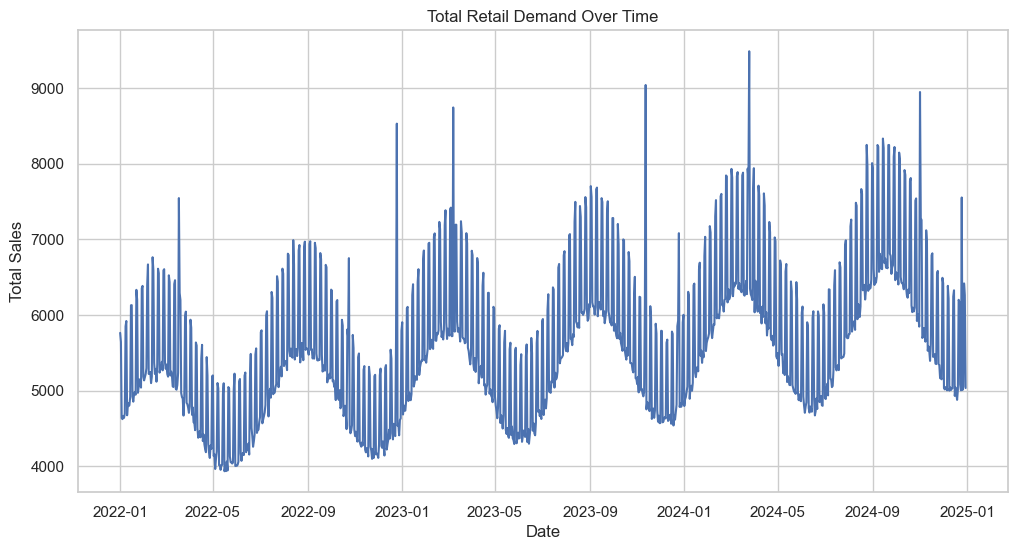

In [17]:
daily_sales = df.groupby("date")["sales"].sum()

plt.figure(figsize=(12,6))
plt.plot(daily_sales)
plt.title("Total Retail Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.savefig("../docs/Total Retail Demand Over Time.png")
plt.show()

Product Demand Distribution

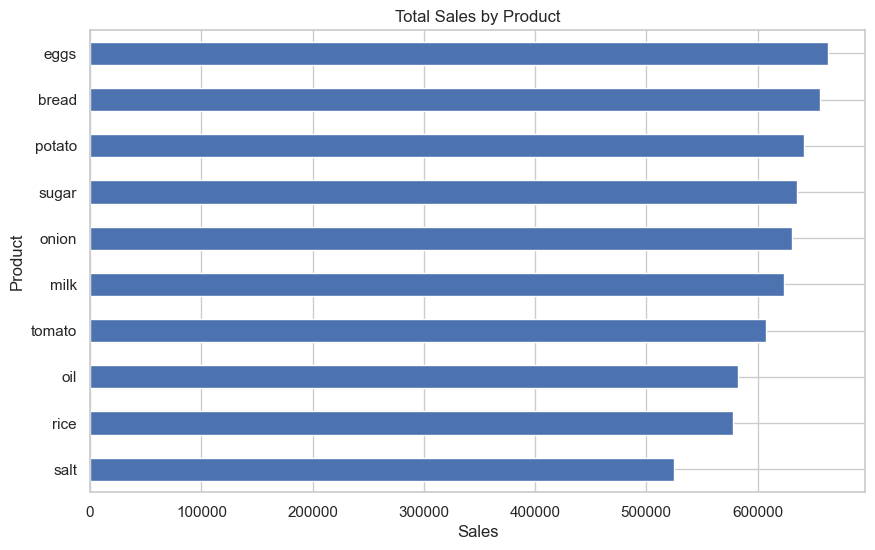

In [4]:
product_sales = df.groupby("product")["sales"].sum().sort_values()

plt.figure(figsize=(10,6))
product_sales.plot(kind="barh")
plt.title("Total Sales by Product")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

Store Performance Heatmap

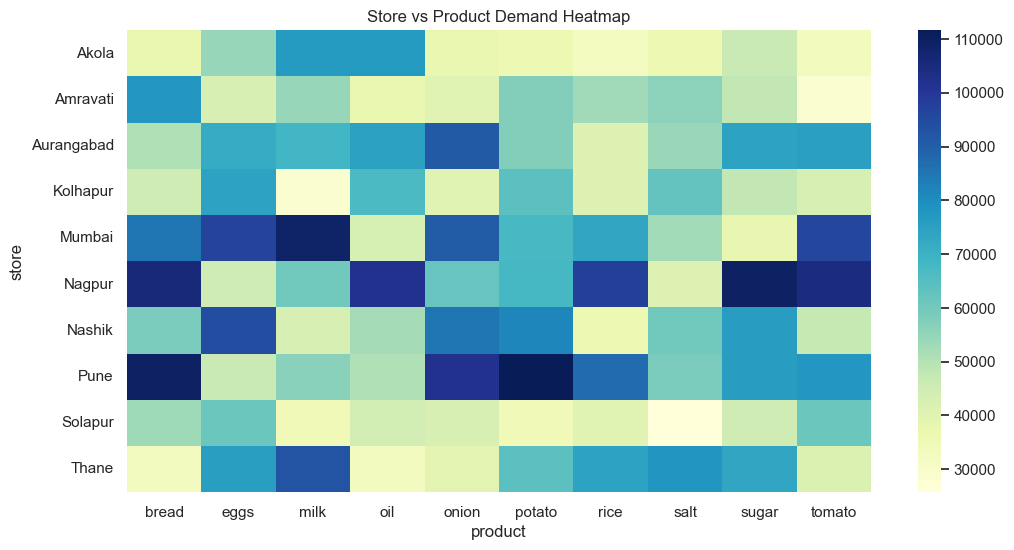

In [16]:
pivot = df.pivot_table(
    values="sales",
    index="store",
    columns="product",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlGnBu")
plt.title("Store vs Product Demand Heatmap")
plt.savefig("../docs/Store vs Product Demand Heatmap.png")
plt.show()

Weekend vs Weekday Demand

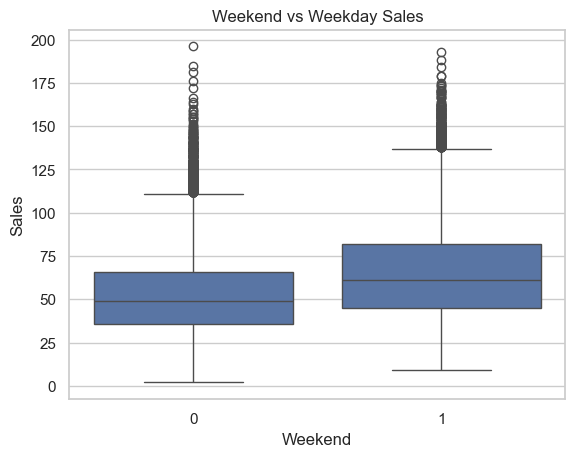

In [14]:
sns.boxplot(
    x="is_weekend",
    y="sales",
    data=df
)

plt.title("Weekend vs Weekday Sales")
plt.xlabel("Weekend")
plt.ylabel("Sales")
plt.savefig("../docs/Weekend vs Weekday Sales.png")
plt.show()



Promotion Impact

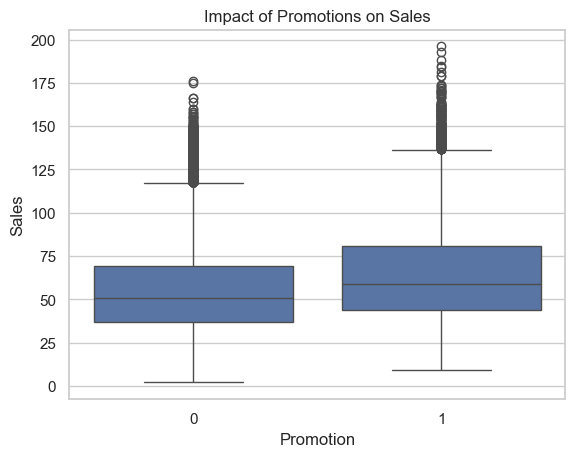

In [15]:
sns.boxplot(
    x="promotion",
    y="sales",
    data=df
)

plt.title("Impact of Promotions on Sales")
plt.xlabel("Promotion")
plt.ylabel("Sales")
plt.savefig("../docs/Impact of Promotions on Sales.png")
plt.show()

<Figure size 640x480 with 0 Axes>

Stockout Analysis

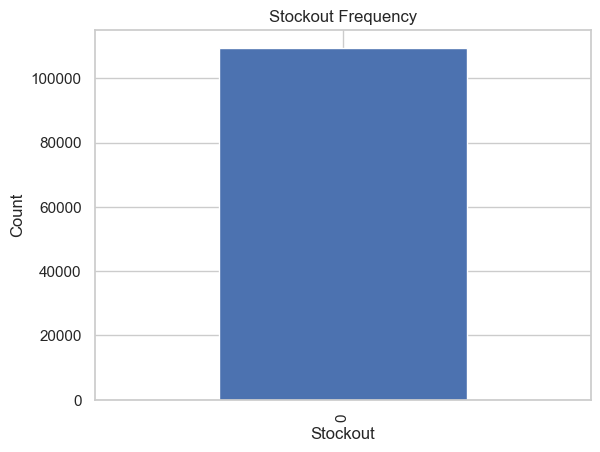

In [8]:
stockouts = df["stockout"].value_counts()

stockouts.plot(kind="bar")

plt.title("Stockout Frequency")
plt.xlabel("Stockout")
plt.ylabel("Count")
plt.show()

In [21]:
restock_df = pd.read_csv("data/restock_recommendations.csv")

restock_df.sort_values("recommended_restock").tail(10)

FileNotFoundError: [Errno 2] No such file or directory: 'data/restock_recommendations.csv'